# SVM Tuning

| | |
|---|---|
| **Algorithm** | Support Vector Classifier (SVC) |
| **Dataset** | Diabetes (Pima Indians), 2,000 (augmented) |
| **Task** | Binary Classification (당뇨 여부) |
| **Metric** | CV Accuracy, CV F1 — 5-fold StratifiedKFold |

## 튜닝 포인트

| # | 튜닝 | 내용 | 기대 효과 |
|---|---|---|---|
| 1 | **C + gamma GridSearchCV** | RBF kernel 핵심 파라미터 탐색 + heatmap | 마진/오분류 트레이드오프 + 커널 폭 최적화 |
| 2 | **kernel 비교** | rbf / linear / poly | 데이터에 맞는 결정경계 선택 |
| 3 | **Scaler 비교** | StandardScaler vs RobustScaler | 이상치 존재 시 스케일러 영향 확인 |

## Imports
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

## Data Loading
---
- `diabetes_2000.csv`: knn_tuning.ipynb에서 Gaussian noise augmentation으로 생성 (768 → 2,000)

In [2]:
df = pd.read_csv('../datasets/diabetes_2000.csv')
print(df.shape)
print(df['Outcome'].value_counts())
df.head()

(2000, 9)
Outcome
0    1302
1     698
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,90.485110,83.156976,26.504492,215.639580,34.547358,0.233607,43,1
1,1,90.000000,62.000000,12.000000,43.000000,27.200000,0.580000,24,0
2,0,134.197203,93.034998,46.224706,145.441016,41.566676,0.361592,27,0
3,1,114.386104,65.126088,35.506463,202.080823,37.973453,0.248906,22,0
4,0,93.074134,67.934380,27.806508,128.313629,42.530146,0.406004,21,0


In [3]:
X = df.drop(columns='Outcome').values
y = df['Outcome'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Base Model
---
- RobustScaler + SVC(kernel='rbf', C=1.0, gamma='scale')

In [4]:
base_pl = Pipeline([('scaler', RobustScaler()), ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))])

base_acc = cross_val_score(base_pl, X, y, cv=cv, scoring='accuracy').mean()
base_f1  = cross_val_score(base_pl, X, y, cv=cv, scoring='f1').mean()
print(f'Base — CV Accuracy: {base_acc:.4f}  CV F1: {base_f1:.4f}')

Base — CV Accuracy: 0.8190  CV F1: 0.7138


## Tuning 1: C + gamma GridSearchCV
---

| 파라미터 | 역할 | 작을 때 | 클 때 |
|---|---|---|---|
| `C` | 마진 vs 오분류 트레이드오프 | 넓은 마진, 오분류 허용 (과소적합) | 오분류 최소화, 좁은 마진 (과적합) |
| `gamma` | RBF 커널 영향 반경 | 멀리 있는 샘플도 영향 → 부드러운 경계 | 가까운 샘플만 영향 → 복잡한 경계 (과적합) |

- 두 파라미터가 상호작용하므로 GridSearchCV로 함께 탐색한다.

In [5]:
pipeline = Pipeline([('scaler', RobustScaler()), ('svc', SVC(kernel='rbf', random_state=42))])

param_grid = {
    'svc__C':     [0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 'scale']
}

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X, y)

print(f'Best params : {grid.best_params_}')
print(f'Best CV F1  : {grid.best_score_:.4f}')

cg_acc = cross_val_score(grid.best_estimator_, X, y, cv=cv, scoring='accuracy').mean()
cg_f1  = grid.best_score_

Best params : {'svc__C': 100, 'svc__gamma': 'scale'}
Best CV F1  : 0.8434


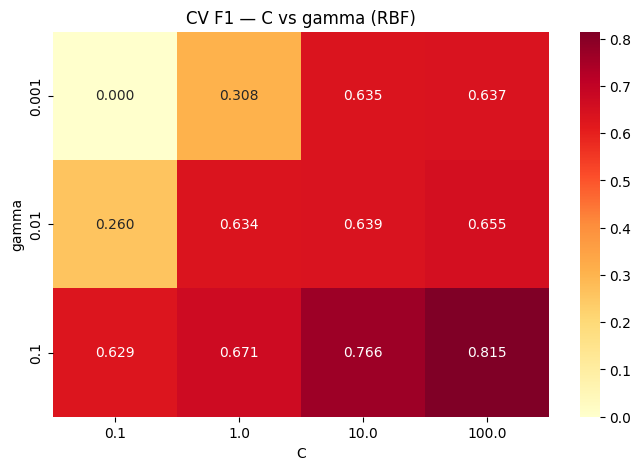

In [6]:
# C x gamma heatmap (숫자 gamma만 사용)
df_cv = pd.DataFrame(grid.cv_results_)
df_cv['C']     = df_cv['params'].apply(lambda p: p['svc__C'])
df_cv['gamma'] = df_cv['params'].apply(lambda p: p['svc__gamma'])

df_num = df_cv[df_cv['gamma'].apply(lambda g: isinstance(g, float))]
pivot  = df_num.pivot(index='gamma', columns='C', values='mean_test_score')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('CV F1 — C vs gamma (RBF)')
plt.show()

## Tuning 2: kernel 비교
---

| kernel | 특징 | 적합한 경우 |
|---|---|---|
| `rbf` | 비선형, 방사형 | 일반적 비선형 데이터 |
| `linear` | 선형 결정경계 | feature가 많고 sample이 적을 때 |
| `poly` | 다항식 경계 | 명시적인 다항 관계가 있는 경우 |

In [7]:
best_C     = grid.best_params_['svc__C']
best_gamma = grid.best_params_['svc__gamma']

kernel_results = {}
for kernel in ['rbf', 'linear', 'poly']:
    pl = Pipeline([('scaler', RobustScaler()), ('svc', SVC(kernel=kernel, C=best_C, random_state=42))])
    acc = cross_val_score(pl, X, y, cv=cv, scoring='accuracy').mean()
    f1  = cross_val_score(pl, X, y, cv=cv, scoring='f1').mean()
    kernel_results[kernel] = (acc, f1)
    print(f'{kernel:8s} — CV Accuracy: {acc:.4f}  CV F1: {f1:.4f}')

rbf      — CV Accuracy: 0.8930  CV F1: 0.8434
linear   — CV Accuracy: 0.7710  CV F1: 0.6351
poly     — CV Accuracy: 0.8200  CV F1: 0.7157


## Tuning 3: Scaler 비교
---

| Scaler | 방식 | 특징 |
|---|---|---|
| `StandardScaler` | (x - mean) / std | 이상치가 mean/std에 영향 → 이상치에 민감 |
| `RobustScaler` | (x - median) / IQR | 중앙값과 IQR 사용 → 이상치에 강건 |

- Diabetes 데이터는 Insulin 등 0값이 많아 이상치가 존재한다.

In [8]:
scaler_results = {}
for name, sc in [('StandardScaler', StandardScaler()), ('RobustScaler', RobustScaler())]:
    pl = Pipeline([('scaler', sc), ('svc', SVC(kernel='rbf', C=best_C, gamma=best_gamma, random_state=42))])
    acc = cross_val_score(pl, X, y, cv=cv, scoring='accuracy').mean()
    f1  = cross_val_score(pl, X, y, cv=cv, scoring='f1').mean()
    scaler_results[name] = (acc, f1)
    print(f'{name:18s} — CV Accuracy: {acc:.4f}  CV F1: {f1:.4f}')

StandardScaler     — CV Accuracy: 0.9000  CV F1: 0.8534
RobustScaler       — CV Accuracy: 0.8930  CV F1: 0.8434


## 결과 비교
---
- 모든 모델을 동일한 5-fold StratifiedKFold CV로 평가

                 Model  CV Accuracy    CV F1 Acc Delta F1 Delta
     Base (C=1, scale)        0.819 0.713832   +0.0000  +0.0000
Tuning 1: GridSearchCV        0.893 0.843422   +0.0740  +0.1296


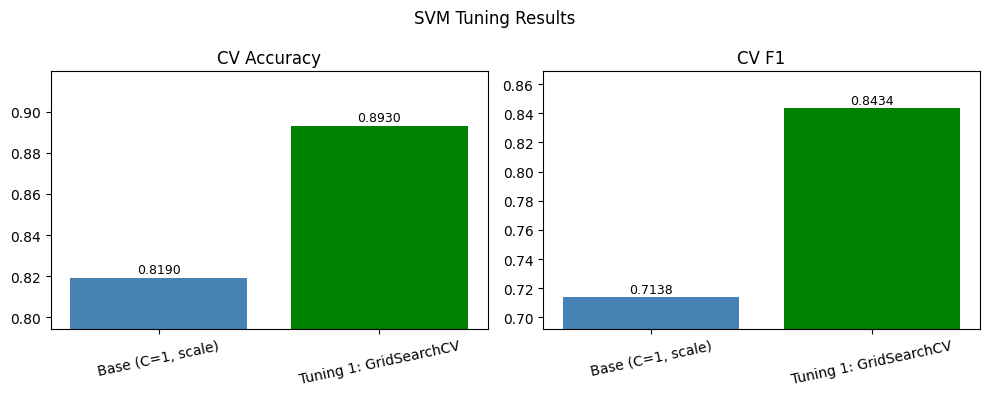


              precision    recall  f1-score   support

 No Diabetes       0.90      0.93      0.92       260
    Diabetes       0.87      0.81      0.84       140

    accuracy                           0.89       400
   macro avg       0.89      0.87      0.88       400
weighted avg       0.89      0.89      0.89       400



In [9]:
results = pd.DataFrame({
    'Model':       ['Base (C=1, scale)', 'Tuning 1: GridSearchCV'],
    'CV Accuracy': [base_acc, cg_acc],
    'CV F1':       [base_f1,  cg_f1]
})
results['Acc Delta'] = (results['CV Accuracy'] - base_acc).map(lambda x: f'{x:+.4f}')
results['F1 Delta']  = (results['CV F1']       - base_f1 ).map(lambda x: f'{x:+.4f}')
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ['CV Accuracy', 'CV F1']):
    bars = ax.bar(results['Model'], results[col], color=['steelblue', 'green'])
    ax.set_ylim(results[col].min() * 0.97, results[col].max() * 1.03)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=12)
    for bar, val in zip(bars, results[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('SVM Tuning Results')
plt.tight_layout()
plt.show()

print()
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
final = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
final.fit(X_train, y_train)
print(classification_report(y_test, final.predict(X_test), target_names=['No Diabetes', 'Diabetes']))